# Are Young People Being Priced Out of Life in the UK?

### A Data-Driven Analysis of Wages, Housing, and Living Costs

Over the past two decades, house prices in the UK have risen dramatically, while wages have grown much more slowly. This project investigates whether young people are increasingly unable to afford housing and basic living costs.

## Research Question

Are housing and living costs increasing faster than wages in the UK, making life less affordable for young people?

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
plt.style.use("default")

main_data = pd.read_csv('/mnt/c/Users/paul/OneDrive/Ben/Uni/Year_2/Data_Science/Are-Young-People-Priced-Out-of-Life-Project/data/Processed/main_data.csv')
main_data_short = pd.read_csv('/mnt/c/Users/paul/OneDrive/Ben/Uni/Year_2/Data_Science/Are-Young-People-Priced-Out-of-Life-Project/data/Processed/main_data_short.csv')
main_data.head()

,Year,Wages,House_Price,CPI_All,CPI_Food,CPI_Housing,CPI_Transport,CPI_Education,Real_Wages,Real_House_Price,...,Cost_Pressure_Indicator,Wage_Index,House_Price_Index,Real_Wage_Index,Real_House_Price_Index,CPI_All_Index,CPI_Food_Index,CPI_Housing_Index,CPI_Transport_Index,CPI_Education_Index
0,1998,334.9,70313.05,71.2,66.3,52.7,64.0,27.3,470.37,98754.29,...,NaN,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
1,1999,345.5,77961.38,72.1,66.4,53.8,65.3,28.8,479.20,108129.51,...,2.44,103.17,110.88,101.88,109.49,101.26,100.15,102.09,102.03,105.49
2,2000,359.0,89596.59,72.7,66.1,54.6,67.1,30.5,493.81,123241.53,...,2.42,107.20,127.43,104.98,124.80,102.11,99.70,103.61,104.84,111.72
3,2001,375.9,96892.34,73.6,68.6,55.8,67.1,32.4,510.73,131647.20,...,3.05,112.24,137.80,108.58,133.31,103.37,103.47,105.88,104.84,118.68
4,2002,390.9,112519.67,74.5,69.2,57.2,67.5,34.2,524.70,151033.11,...,2.38,116.72,160.03,111.55,152.94,104.63,104.37,108.54,105.47,125.27


In [34]:
main_data_short.tail()

,Year,Wages,House_Price,CPI_All,CPI_Food,CPI_Housing,CPI_Transport,CPI_Education,Real_Wages,Real_House_Price,...,House_Price_Index,Real_Wage_Index,Real_House_Price_Index,Rent_Price,Real_Rent_Price,Rent_Price_to_Wage_Ratio,Real_Rent_Price_to_Real_Wage_Ratio,Monthly_Wages,Rent_to_Monthly_Wage_Ratio,Rent_Price_Index
6,2021,610.7,236312.50,111.6,104.2,108.3,120.4,121.5,547.22,211749.55,...,129.63,103.82,116.16,1038.92,930.93,1.70,1.70,2646.37,0.39,112.32
7,2022,641.8,258236.17,121.7,115.5,128.3,134.2,126.5,527.36,212190.77,...,141.66,100.05,116.40,1083.58,890.37,1.69,1.69,2781.13,0.39,117.14
8,2023,687.0,258956.17,130.5,132.3,140.7,134.5,131.0,526.44,198433.84,...,142.06,99.87,108.86,1163.75,891.76,1.69,1.69,2977.00,0.39,125.81
9,2024,728.3,260532.25,133.9,135.8,138.8,134.2,137.1,543.91,194572.26,...,142.92,103.19,106.74,1265.00,944.73,1.74,1.74,3155.97,0.40,136.76
10,2025,766.6,268191.25,138.4,141.5,146.4,137.7,147.4,553.90,193779.80,...,147.12,105.08,106.30,1344.75,971.64,1.75,1.75,3321.93,0.40,145.38


Figure 1:

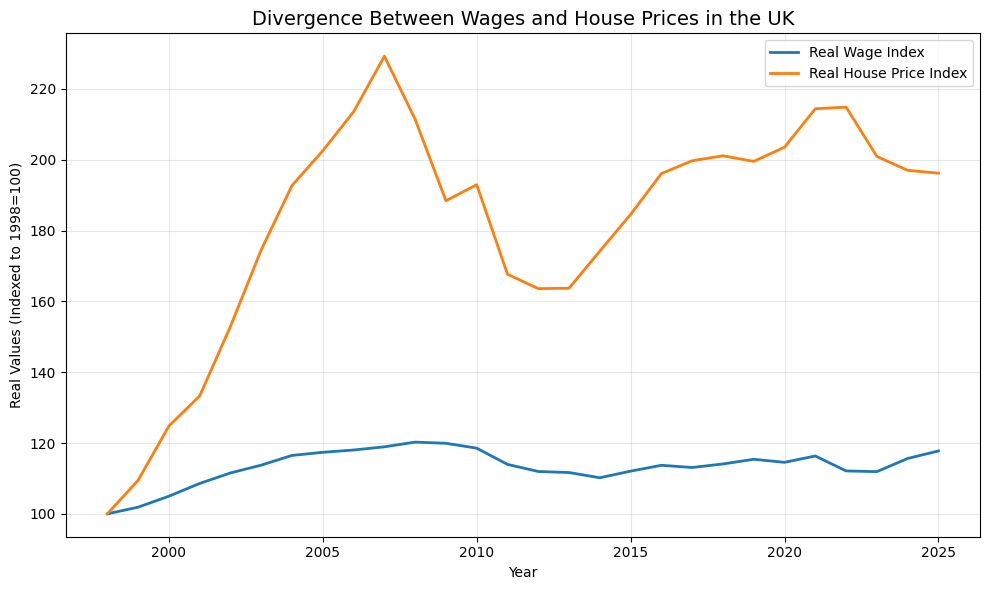

In [35]:
plt.figure(figsize=(10,6))

plt.plot(main_data["Year"], main_data["Real_Wage_Index"], label="Real Wage Index", linewidth=2)
plt.plot(main_data["Year"], main_data["Real_House_Price_Index"], label="Real House Price Index", linewidth=2)

plt.title("Divergence Between Wages and House Prices in the UK", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Real Values (Indexed to 1998=100)")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

We can see that house prices have increased significantly faster than wages, particularly from 2000. This suggests a growing affordability gap with housing becoming increasingly unattainable for young people. Much of this widening was experienced from 1998-2007 where a rapid increase in real house prices was accompanied by a relatively stagnant real wage level. Despite real house prices being much more volatile they have conistently stayed well above the real wage with (using 1998 as the base year) the real house price index being at 196 in 2025 compared to 117 for real wages. This therefore conveys the idea of young people being priced out of buying a home due to the extreme decrease in affordability since 1998.

Figure 2:

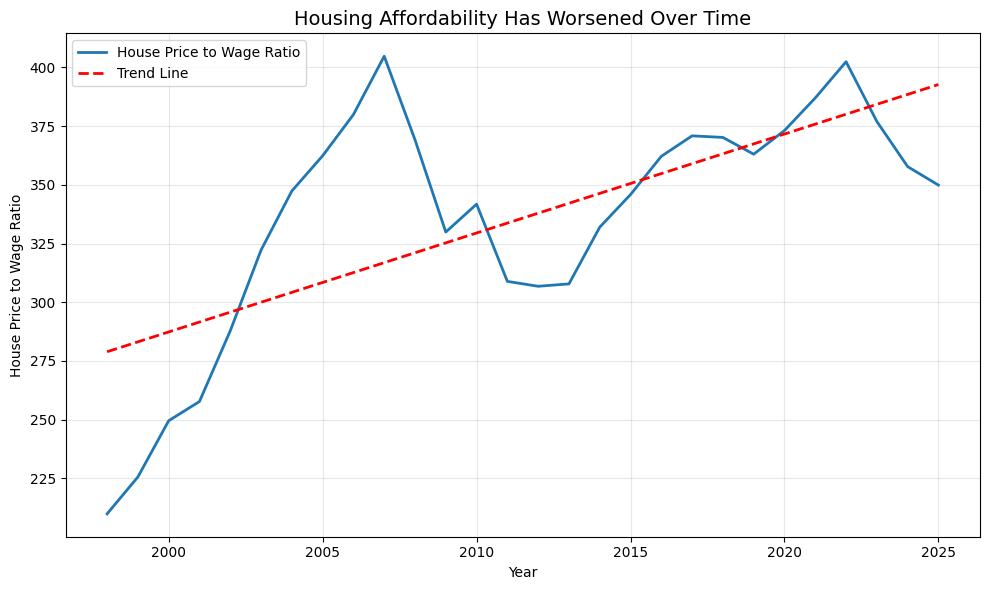

In [36]:
plt.figure(figsize=(10,6))

plt.plot(main_data["Year"], main_data["House_Price_to_Wage_Ratio"], label="House Price to Wage Ratio", linewidth=2)

plt.title("Housing Affordability Has Worsened Over Time", fontsize=14)
plt.xlabel("Year")
plt.ylabel("House Price to Wage Ratio")

plt.grid(alpha=0.3)
plt.tight_layout()

x = main_data["Year"]
y = main_data["House_Price_to_Wage_Ratio"]

m, c = np.polyfit(x, y, 1)
trend = m * x + c

plt.plot(x, trend, linestyle="--", color="red", linewidth=2, label="Trend Line")

plt.legend()

plt.show()

The house price-to-wage ratio has steadily increased, meaning that buying a home requires more years of income than before. We can easily see this occurring by looking at the trend line showing the consistent upward direction of the ratio. This implies that house prices are becoming relatively more expensive compared to wages despite fluctuations.

Figure 3:

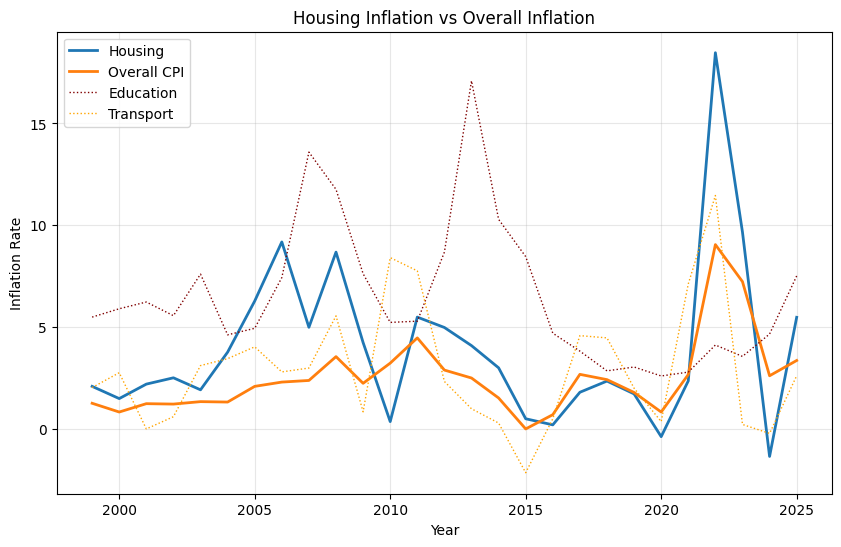

In [37]:
plt.figure(figsize=(10,6))

plt.plot(main_data["Year"], main_data["Housing_Inflation"], label="Housing", linewidth=2)
plt.plot(main_data["Year"], main_data["Overall_Inflation"], label="Overall CPI", linewidth=2)
plt.plot(main_data["Year"], main_data["Education_Inflation"], label="Education", linewidth=1, linestyle=":", color="maroon")
plt.plot(main_data["Year"], main_data["Transport_Inflation"], label="Transport", linewidth=1, linestyle=":", color="orange")

plt.legend()
plt.title("Housing Inflation vs Overall Inflation")
plt.xlabel("Year")
plt.ylabel("Inflation Rate")

plt.grid(alpha=0.3)
plt.show()

Looking at the inflation trends, you can see that the costs young people face have been rising faster than general prices for a long time. Housing inflation sits above overall CPI for most of the period, which means the basic cost of having somewhere to live has been getting harder to manage, especially for people who are renting or trying to buy for the first time. Education and transport costs also grow more quickly than overall inflation, and those are areas where younger people tend to spend a bigger share of their income. Taken together, the data suggests that the essentials needed to build an independent life have become increasingly expensive relative to everything else, which supports the idea that young people are being priced out of life.

Figure 4:

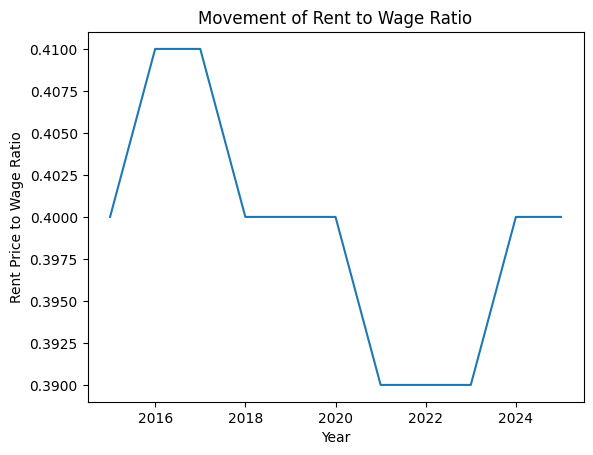

In [38]:
plt.figure()

plt.plot(main_data_short["Year"], main_data_short["Rent_to_Monthly_Wage_Ratio"])

plt.title("Movement of Rent to Wage Ratio")
plt.xlabel("Year")
plt.ylabel("Rent Price to Wage Ratio")

plt.show()

The rent‑to‑wage ratio shows a slightly different picture compared to the other affordability measures. Instead of a steady decline in affordability, the ratio actually improves for a few year. This suggests that rent became a bit more manageable relative to wages during that period. However, this improvement doesn’t last. By the end of the series, the ratio climbs back to earlier levels, which implies that the dip was likely driven by short‑term factors rather than a real long‑term shift. In the context of whether young people are being priced out of life, this graph doesn’t contradict the overall argument. It just shows that rent affordability fluctuates more and can temporarily improve, even while the overall trend in housing and living costs continues to put pressure on younger people.

Figure 5:

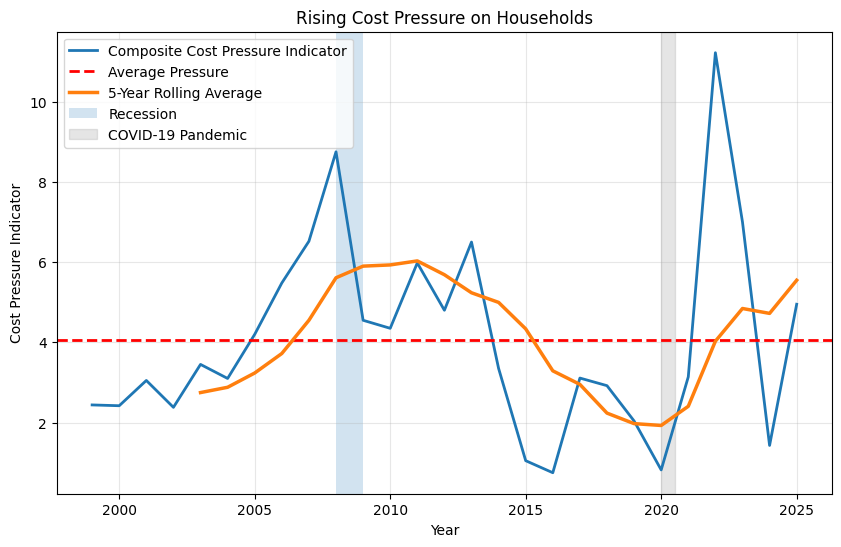

In [39]:
plt.figure(figsize=(10,6))

plt.plot(main_data["Year"], main_data["Cost_Pressure_Indicator"], linewidth=2, label="Composite Cost Pressure Indicator")
plt.axhline(y=main_data["Cost_Pressure_Indicator"].mean(), linestyle="--", color="red", linewidth=2, label="Average Pressure")
main_data["Cost_Pressure_Rolling"] = main_data["Cost_Pressure_Indicator"].rolling(window=5).mean()
plt.plot(main_data["Year"], main_data["Cost_Pressure_Rolling"], label="5-Year Rolling Average", linewidth=2.5)


plt.axvspan(2008, 2009, alpha=0.2, label="Recession")
plt.axvspan(2020, 2020.5, alpha=0.2, label="COVID-19 Pandemic", color="gray")


plt.title("Rising Cost Pressure on Households")
plt.xlabel("Year")
plt.ylabel("Cost Pressure Indicator")


plt.legend()

plt.grid(alpha=0.3)

plt.show()

The cost‑pressure indicator (mean of housing, transport, education and food inflation) shows that households have been facing steadily rising financial strain over the long run, even though recessions and the pandemic create short‑term spikes and dips. What stands out is that despite these temporary disruptions, the overall direction is upward. That means the basic cost of maintaining a household has become more demanding over time. For young people, who typically have lower incomes, less savings, and less job security, this rising pressure makes it harder to cover essential expenses and build financial stability. So while economic shocks clearly intensify the strain, the broader trend supports the idea that young people are being priced out of life because the underlying cost pressures keep increasing regardless of the economic cycle.

## A deeper look at the data
#### Regressions:

In [40]:
main_data["d_ratio"] = main_data["House_Price_to_Wage_Ratio"].pct_change()

df_reg = main_data.dropna()

import statsmodels.api as sm

X = df_reg[[
    "Housing_Inflation",
    "Overall_Inflation"
]]

y = df_reg["d_ratio"]

X = sm.add_constant(X)

model_main = sm.OLS(y, X).fit()

print(model_main.summary())

                            OLS Regression Results                            
Dep. Variable:                d_ratio   R-squared:                       0.180
Model:                            OLS   Adj. R-squared:                  0.098
Method:                 Least Squares   F-statistic:                     2.190
Date:                Thu, 23 Apr 2026   Prob (F-statistic):              0.138
Time:                        20:11:57   Log-Likelihood:                 35.049
No. Observations:                  23   AIC:                            -64.10
Df Residuals:                      20   BIC:                            -60.69
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.0418      0.02

## Regression Results

The regression results suggest that inflation on its own doesn’t explain much of the year‑to‑year movement in the affordability ratio. The model’s R‑squared is only 0.18, meaning housing and overall inflation together account for just 18% of the variation in changes to affordability. Neither variable is statistically significant: housing inflation has a coefficient of 0.0057 with a p‑value of 0.244, and overall inflation has a coefficient of –0.0202 with a p‑value of 0.061, which is close but still above the usual 0.05 threshold. Even the constant term, at 0.0418 with a p‑value of 0.055, is only borderline significant. Taken together, these figures show that affordability tends to worsen slightly over time regardless of inflation levels, and that short‑term inflation shocks don’t reliably drive changes in the affordability ratio. This supports the idea that the pressures facing young people are more structural than cyclical — inflation may add to the strain, but it doesn’t fully explain why affordability keeps deteriorating


## How current levels compare to affordability standards

To put these trends into context, it helps to compare them with commonly used affordability thresholds. Housing researchers often consider rent unaffordable when it exceeds around 30% of income, and house‑price‑to‑income ratios above five are typically viewed as stretched. While my indicators are constructed differently, the upward movement in both the rent‑to‑wage ratio and the house‑price‑to‑wage ratio shows that young people are moving closer to the kinds of levels associated with affordability pressure. Even the temporary improvement in rent affordability sits within a range that still reflects financial strain. Using these benchmarks reinforces the idea that the long‑term trends in my data represent more than just fluctuations — they point toward conditions that are widely recognised as difficult for younger households to manage.

We can see that despite the relative slight increase in affordability of rent it stays very much above the perceived threshold of 30%. It stays at an average of just under 40% which is well above this boundary.

## Limitations

- Rent data only available from 2015 reducing sample size and ability to look at longer term trends.
- National averages hide regional differences and fluctuations with the possibility of some regions pricing out young people much more than others
- Does not account for wealth with the possibility of younger people perhaps inheriting wealth in ways other than wages improving what they can afford
- Limited sample size for the regression, reducing the strength of the arguement it conveys as it is harder to detect meaningful relationships
- The cost pressure indicator is constructed and not observed so different component choices or weightings could lead to different results.
- Potential measurement inconsistencies due to using data from multiple different sources

## Conclusion

Taken together, the evidence from the graphs and the regression points to a clear pattern: the financial pressures facing young people have been building for years and are driven more by long‑term structural issues than short‑term shocks. Housing inflation consistently rises faster than overall prices, education and transport costs outpace general inflation, and the broader cost‑pressure indicator shows a steady upward trend even outside recession periods. Although the rent‑to‑wage ratio briefly improves, it returns to previous levels, suggesting that any relief is temporary rather than a genuine shift in affordability. The regression reinforces this picture by showing that inflation alone explains only a small share of the changes in affordability, with an R‑squared of 0.18 and no statistically significant predictors. Altogether, the results indicate that young people are not being priced out of life because of isolated economic events, but because the underlying cost of essential goods and services has been rising faster than their ability to keep up.